In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve

project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src").is_dir())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.train import DATA_URL, load_data, clean_data, prepare_features

In [3]:
df = load_data(DATA_URL)
df = clean_data(df)
X, y = prepare_features(df)

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

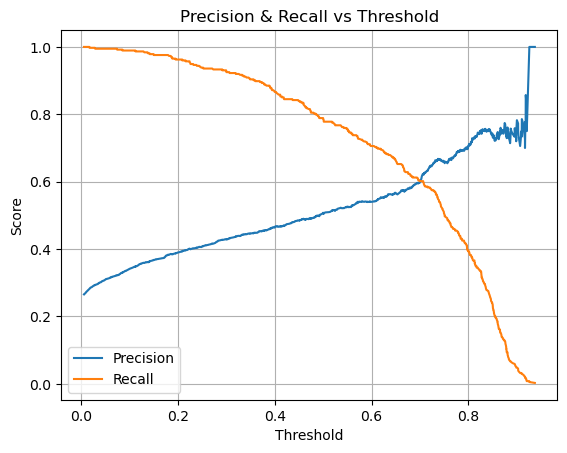

In [9]:
y_scores = pipeline.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision & Recall vs Threshold')
plt.grid(True)
plt.show()